In [5]:
# Character level language model

In [6]:
import torch

In [7]:
names = open("/Users/deepakkumar/Downloads/firstnames.txt", "r").read().split("\n")

In [8]:
len(names)

1166

In [9]:
names = list(map(lambda x: x.lower(), names))

In [10]:
names = [name for name in names if len(name) > 0]

In [11]:
min(len(w) for w in names)

2

In [12]:
max(len(w) for w in names)

14

In [13]:
names = sorted(names)

In [14]:
names[:10]

['aadharsh',
 'aadil',
 'aaditya',
 'aakanksha',
 'aakash',
 'aakriti',
 'aamra',
 'aanchal',
 'aarvi',
 'aaryan']

In [15]:
b = {}
for name in names:
    chs = ['<S>'] + list(name) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [16]:
# NOTE Sort dict by value
sorted(b.items(), key=lambda kv: kv[1])

[(('b', 'b'), 1),
 (('y', 's'), 1),
 (('u', 'z'), 1),
 (('a', 'e'), 1),
 (('f', 'z'), 1),
 (('l', 'k'), 1),
 (('n', 'w'), 1),
 (('r', 'w'), 1),
 (('q', 's'), 1),
 (('n', 'l'), 1),
 (('e', 'q'), 1),
 (('u', 'a'), 1),
 (('z', 'm'), 1),
 (('b', 'l'), 1),
 (('l', 'b'), 1),
 (('w', 'n'), 1),
 (('r', 'r'), 1),
 (('p', 's'), 1),
 (('v', 'b'), 1),
 (('v', 'd'), 1),
 (('h', 'd'), 1),
 (('g', 'v'), 1),
 (('d', 'w'), 1),
 (('r', 'h'), 1),
 (('f', 'u'), 1),
 (('r', 'q'), 1),
 (('l', 'd'), 1),
 (('i', 'o'), 1),
 (('t', 'c'), 1),
 (('o', 'i'), 1),
 (('f', 'r'), 1),
 (('y', 'k'), 1),
 (('o', 'y'), 1),
 (('h', 'b'), 1),
 (('k', 'o'), 1),
 (('a', 'x'), 1),
 (('x', 'm'), 1),
 (('c', 'k'), 1),
 (('m', 't'), 1),
 (('h', 's'), 1),
 (('c', 'a'), 1),
 (('y', 't'), 1),
 (('g', 'j'), 1),
 (('v', 'o'), 1),
 (('h', 'c'), 1),
 (('m', 'h'), 1),
 (('o', 'j'), 1),
 (('h', 'j'), 1),
 (('i', 'u'), 1),
 (('c', 'e'), 1),
 (('m', 'v'), 1),
 (('<S>', 'q'), 1),
 (('j', 'k'), 1),
 (('j', 'n'), 1),
 (('j', 'v'), 1),
 (('z', 

In [17]:
# vocab
vocab = sorted(set("".join(names)))

In [18]:
vocab

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Building a bigram language model

In [19]:
# NOTE: building a dict by enumerating a list of chars
stoi = {s:i+1 for i,s in enumerate(vocab)}
# stoi['<S>'] = 26
# stoi['<E>'] = 27
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [20]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [21]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [22]:
N = torch.zeros((27, 27), dtype=torch.int32)
for name in names:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        i, j = stoi[ch1], stoi[ch2]
        N[i, j] += 1

In [23]:
N[0,0].item()

0

In [24]:
import matplotlib.pyplot as plt

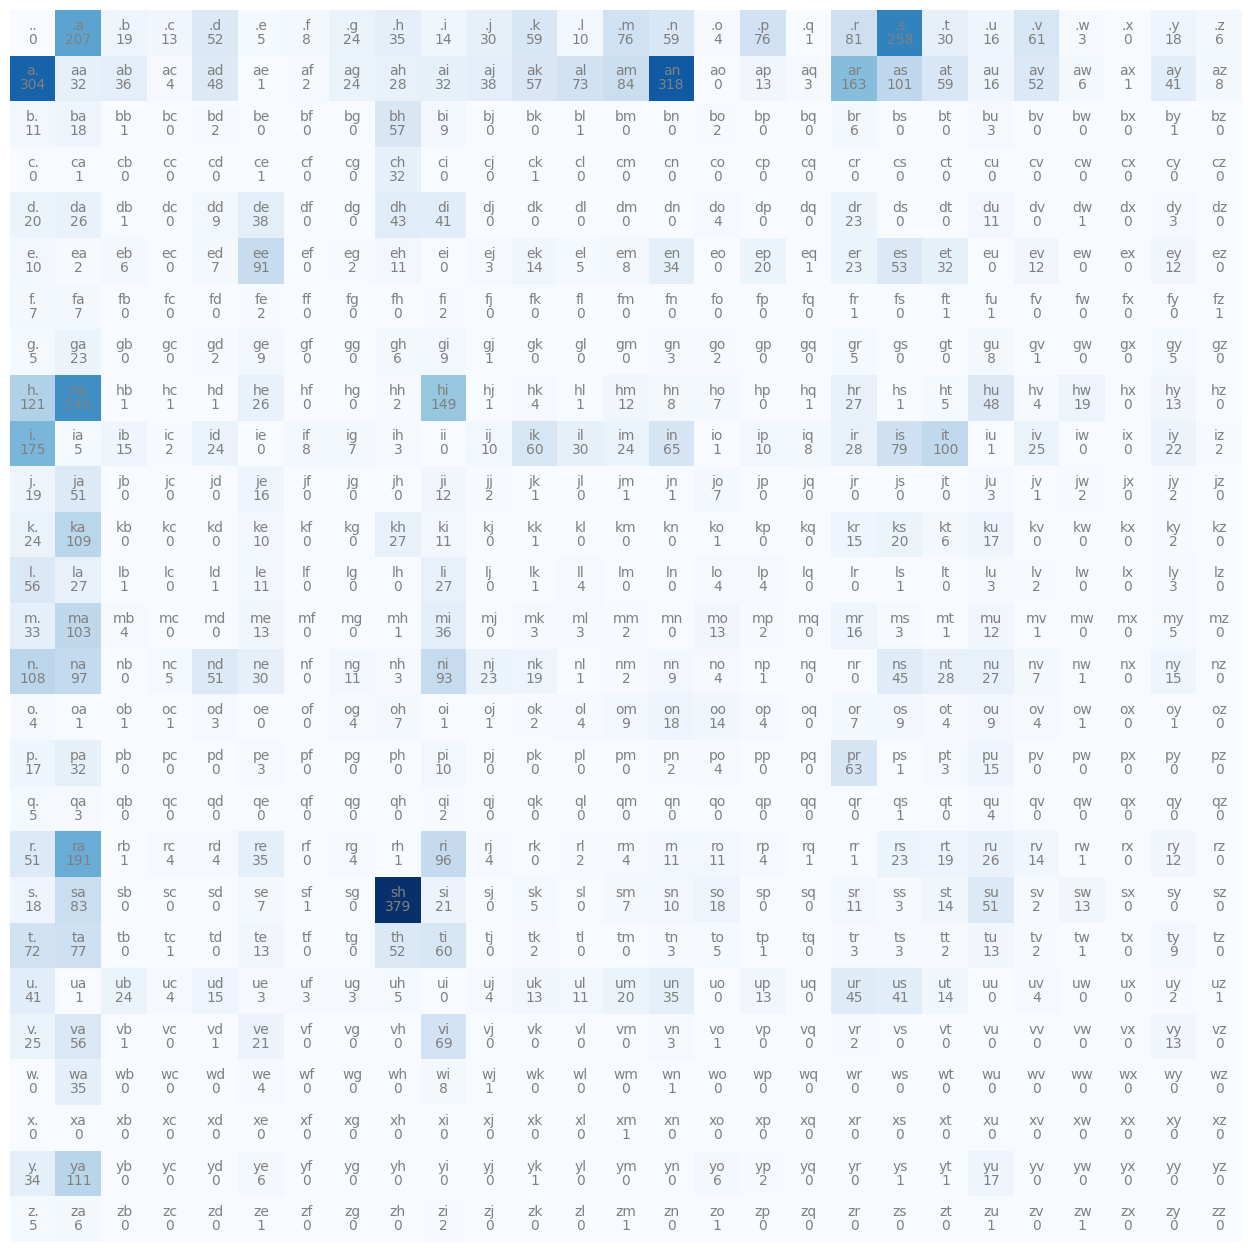

In [25]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
plt.axis("off")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="gray")

In [26]:
g = torch.Generator().manual_seed(2048)

In [27]:
# Model smoothening
# Here 1 is added (or any number) to smoothen the model this eliminates predicting that a name has 0 probability
# Here 1 is used to indicate that's the minium possible times a character can follow another. The more the smoothening the more smooth(equal probability) the model is.
P = (N + 1).float() 

In [28]:
P /= P.sum(1, keepdim=True) # dangerous code read about broadcasting, outputs a column vector of size 27 x 1

In [29]:
P.sum() # becasue probabiloties in each row add upto 1

tensor(27.0000)

In [30]:
P[0].sum()

tensor(1.)

In [31]:
P

tensor([[0.0008, 0.1745, 0.0168, 0.0117, 0.0445, 0.0050, 0.0076, 0.0210, 0.0302,
         0.0126, 0.0260, 0.0503, 0.0092, 0.0646, 0.0503, 0.0042, 0.0646, 0.0017,
         0.0688, 0.2173, 0.0260, 0.0143, 0.0520, 0.0034, 0.0008, 0.0159, 0.0059],
        [0.1941, 0.0210, 0.0236, 0.0032, 0.0312, 0.0013, 0.0019, 0.0159, 0.0185,
         0.0210, 0.0248, 0.0369, 0.0471, 0.0541, 0.2031, 0.0006, 0.0089, 0.0025,
         0.1044, 0.0649, 0.0382, 0.0108, 0.0337, 0.0045, 0.0013, 0.0267, 0.0057],
        [0.0870, 0.1377, 0.0145, 0.0072, 0.0217, 0.0072, 0.0072, 0.0072, 0.4203,
         0.0725, 0.0072, 0.0072, 0.0145, 0.0072, 0.0072, 0.0217, 0.0072, 0.0072,
         0.0507, 0.0072, 0.0072, 0.0290, 0.0072, 0.0072, 0.0072, 0.0145, 0.0072],
        [0.0161, 0.0323, 0.0161, 0.0161, 0.0161, 0.0323, 0.0161, 0.0161, 0.5323,
         0.0161, 0.0161, 0.0323, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161,
         0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161, 0.0161],
        [0.0850, 0.1093,

In [32]:
# sample 
for i in range(10):
    ix = 0
    gen_chars = []
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0: # end token
            break;
        gen_chars.append(itos[ix])
    print("".join(gen_chars))

a
adrana
va
detyon
shi
ftanananlonamaunfyumirva
a
ibhrinupomltooscha
ndrba
ra


In [33]:
ix = 0
p = N[ix].float()
p = p / p.sum()
print(p)
torch.multinomial(p, num_samples=1, replacement=True, generator=g)

tensor([0.0000, 0.1777, 0.0163, 0.0112, 0.0446, 0.0043, 0.0069, 0.0206, 0.0300,
        0.0120, 0.0258, 0.0506, 0.0086, 0.0652, 0.0506, 0.0034, 0.0652, 0.0009,
        0.0695, 0.2215, 0.0258, 0.0137, 0.0524, 0.0026, 0.0000, 0.0155, 0.0052])


tensor([1])

Likelihood is the product of probability assigned by the model for each outcome.
Likelihood of n probabilities 
likelihood = P1, P2, P3 ...Pn = P1 * P2 * P3 ...*Pn
Since this is going to be small number we can take the log of this
log(likelihood) = log(P1) + log(P2) .... + log(Pn)
**Higher the number better the model**

The objective of our training is to maximize the log likelihood. As a better way we can negate log likelihood and use negative log likelihood (nll). The smaller the nll the better it is.

Another approach is to take an average of nll and use avg nll.

nll or average nll can be a an excellent loss function during the training.

avg_nll = - (log(P1) + log(P2) ... + log(Pn)) / n

In [34]:
# quality of the model, loss calculation
log_likelihood = 0.0
n = 0
for name in ["deepakb"]:
    chs = ['.'] + list(name) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        i, j = stoi[ch1], stoi[ch2]
        p = P[i, j]
        logprob = torch.log(p)
        log_likelihood += logprob
        n += 1
        # print(f"{ch1}{ch2} P={p:.4f}")

print(f"{log_likelihood=}")
nll = -log_likelihood
print(f"Avg likelihood={nll/n} {nll=},{n=}")

log_likelihood=tensor(-22.2552)
Avg likelihood=2.781900644302368 nll=tensor(22.2552),n=8


# neural network approach

In [35]:
# preparing the input and output, xs contains the first item in bigram nad y contains the second item in the bigram
xs = []
ys = []
for name in names[:1]:
    name = list("." + name + ".")
    for ch1, ch2 in zip(name, name[1:]):
        i, j = stoi[ch1], stoi[ch2]
        xs.append(i)
        ys.append(j)
        print(f"{ch1}{ch2} ({i},{j})")        

.a (0,1)
aa (1,1)
ad (1,4)
dh (4,8)
ha (8,1)
ar (1,18)
rs (18,19)
sh (19,8)
h. (8,0)


In [36]:
XS, YS = torch.tensor(xs), torch.tensor(ys)

In [37]:
XS.dtype, XS.shape

(torch.int64, torch.Size([9]))

In [38]:
# XS and YS contains integer values
# neural networks cannot work with integers directly therefore we need to encode the integers into vectors
# ONE_HOT encoding for integers
# for n creates a vector of size n with all zeros vector except for the nth element set to 1
# 4 (10) -> 0 0 0 0 1 0 0 0 0 0
# 0 (10) -> 1 0 0 0 0 0 0 0 0 0
# 9 (10) -> 0 0 0 0 0 0 0 0 0 1

import torch.nn.functional as F

In [39]:
# one_hot does not provide a way to specify dtype so we need cast using float() function as below
xenc = F.one_hot(XS, num_classes=27).float()

In [40]:
xenc.shape

torch.Size([9, 27])

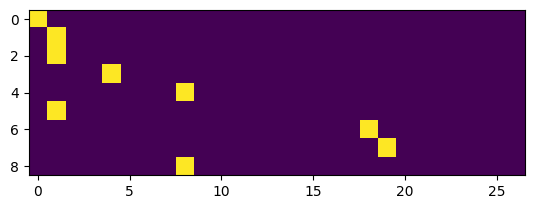

In [41]:
plt.imshow(xenc)

In [42]:
yenc = F.one_hot(YS, num_classes=27).float()

In [43]:
yenc

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0

In [44]:
# so out input contains items of size 27 bits.

In [45]:
# Initialize weights randomly, with normal distribution
# Using a single neuron

W = torch.randn((27, 1))

In [46]:
# wx + b (b bias)
# number of inputs in xenc is called batch size
xenc @ W

tensor([[-0.5393],
        [-0.2704],
        [-0.2704],
        [ 0.1720],
        [ 0.4252],
        [-0.2704],
        [-1.1686],
        [ 0.8992],
        [ 0.4252]])

In [47]:
# Using 27 neurons
W = torch.randn((27,27))

In [48]:
xenc @ W

tensor([[ 1.2819,  0.0491,  1.4142, -0.8982,  0.0234,  0.0509,  0.4757, -0.5090,
         -0.1819, -0.5557,  0.5133, -0.4776, -0.0794, -0.6057, -1.3195, -0.9585,
          0.0838, -0.8008,  0.3333, -0.4515,  0.6089, -2.1111,  1.2661, -0.3078,
          1.8324,  0.4799,  0.6920],
        [ 0.6083,  0.2670,  1.1940, -0.6923, -1.5222,  0.4963,  0.6600, -1.6530,
         -0.3563,  0.8043,  1.2078,  0.0546,  0.0576, -0.0386,  0.2278,  0.0275,
         -0.8190, -1.3508, -0.4378,  3.1676, -0.9891, -0.2599, -0.3043, -0.6964,
         -0.7385,  1.6585, -2.2648],
        [ 0.6083,  0.2670,  1.1940, -0.6923, -1.5222,  0.4963,  0.6600, -1.6530,
         -0.3563,  0.8043,  1.2078,  0.0546,  0.0576, -0.0386,  0.2278,  0.0275,
         -0.8190, -1.3508, -0.4378,  3.1676, -0.9891, -0.2599, -0.3043, -0.6964,
         -0.7385,  1.6585, -2.2648],
        [-1.9494, -0.3149,  1.5706, -1.5346,  0.5917, -1.4238,  0.6804,  1.2679,
         -1.2635, -0.6246, -0.8547, -0.0901,  1.0726, -0.0533, -0.9122, -0.5390

In [53]:
# On interpreting the numbers as logs we can use exponential function to get the values 
# these are called log counts or logits
logits = (xenc @ W).exp()

In [54]:
counts = logits.exp() # softmax step 1
# probability = normalised counts
probs = counts/counts.sum(1, keepdim=True) # softmax step 1
probs

tensor([[5.1191e-02, 3.9851e-03, 8.5220e-02, 2.0949e-03, 3.8800e-03, 3.9927e-03,
         6.9685e-03, 2.5429e-03, 3.2089e-03, 2.4741e-03, 7.4108e-03, 2.5921e-03,
         3.5111e-03, 2.4058e-03, 1.8212e-03, 2.0456e-03, 4.1355e-03, 2.1841e-03,
         5.6279e-03, 2.6350e-03, 8.7635e-03, 1.5735e-03, 4.8386e-02, 2.9074e-03,
         7.2115e-01, 7.0152e-03, 1.0278e-02],
        [3.0457e-10, 1.7905e-10, 1.3154e-09, 8.0004e-11, 6.0334e-11, 2.5071e-10,
         3.3578e-10, 5.8741e-11, 9.7700e-11, 4.5345e-10, 1.3770e-09, 1.3945e-10,
         1.3990e-10, 1.2695e-10, 1.7028e-10, 1.3558e-10, 7.5378e-11, 6.2846e-11,
         9.2489e-11, 1.0000e+00, 7.0355e-11, 1.0488e-10, 1.0142e-10, 7.9840e-11,
         7.8217e-11, 9.2588e-09, 5.3813e-11],
        [3.0457e-10, 1.7905e-10, 1.3154e-09, 8.0004e-11, 6.0334e-11, 2.5071e-10,
         3.3578e-10, 5.8741e-11, 9.7700e-11, 4.5345e-10, 1.3770e-09, 1.3945e-10,
         1.3990e-10, 1.2695e-10, 1.7028e-10, 1.3558e-10, 7.5378e-11, 6.2846e-11,
         9.2489e-

In [55]:
counts # equalent to N matrix above

tensor([[3.6721e+01, 2.8586e+00, 6.1131e+01, 1.5028e+00, 2.7833e+00, 2.8641e+00,
         4.9987e+00, 1.8241e+00, 2.3019e+00, 1.7748e+00, 5.3160e+00, 1.8594e+00,
         2.5186e+00, 1.7258e+00, 1.3064e+00, 1.4673e+00, 2.9666e+00, 1.5667e+00,
         4.0371e+00, 1.8902e+00, 6.2863e+00, 1.1287e+00, 3.4709e+01, 2.0856e+00,
         5.1730e+02, 5.0322e+00, 7.3725e+00],
        [6.2792e+00, 3.6915e+00, 2.7119e+01, 1.6494e+00, 1.2439e+00, 5.1688e+00,
         6.9226e+00, 1.2110e+00, 2.0142e+00, 9.3486e+00, 2.8390e+01, 2.8751e+00,
         2.8842e+00, 2.6173e+00, 3.5106e+00, 2.7953e+00, 1.5540e+00, 1.2957e+00,
         1.9068e+00, 2.0617e+10, 1.4505e+00, 2.1622e+00, 2.0910e+00, 1.6460e+00,
         1.6126e+00, 1.9088e+02, 1.1094e+00],
        [6.2792e+00, 3.6915e+00, 2.7119e+01, 1.6494e+00, 1.2439e+00, 5.1688e+00,
         6.9226e+00, 1.2110e+00, 2.0142e+00, 9.3486e+00, 2.8390e+01, 2.8751e+00,
         2.8842e+00, 2.6173e+00, 3.5106e+00, 2.7953e+00, 1.5540e+00, 1.2957e+00,
         1.9068e+

In [56]:
probs.sum(1, keepdim=True)

tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])

In [57]:
probs[0]

tensor([0.0512, 0.0040, 0.0852, 0.0021, 0.0039, 0.0040, 0.0070, 0.0025, 0.0032,
        0.0025, 0.0074, 0.0026, 0.0035, 0.0024, 0.0018, 0.0020, 0.0041, 0.0022,
        0.0056, 0.0026, 0.0088, 0.0016, 0.0484, 0.0029, 0.7211, 0.0070, 0.0103])

In [58]:
nlls = torch.zeros(5)
for i in range(5):
    x = XS[i].item() 
    y = YS[i].item()
    print(f"Bigram example {i+1}: {itos[x]}{itos[y]}, (indexes {x},{y})")
    print("Input to the neural net", x)
    print("Output from the neural net", probs[i])
    print("Actual output(actual next char)", itos[y], y)
    p = probs[i, y]
    print("Probability assigned by the neural network to the next char", p.item())
    logp = torch.log(p)
    print("Log likelihood", logp.item())
    nll = -logp
    print("Negative log likelihood", nll.item())
    nlls[i] = nll
    print("Average log likelihood",nlls.mean().item())

    

Bigram example 1: .a, (indexes 0,1)
Input to the neural net 0
Output from the neural net tensor([0.0512, 0.0040, 0.0852, 0.0021, 0.0039, 0.0040, 0.0070, 0.0025, 0.0032,
        0.0025, 0.0074, 0.0026, 0.0035, 0.0024, 0.0018, 0.0020, 0.0041, 0.0022,
        0.0056, 0.0026, 0.0088, 0.0016, 0.0484, 0.0029, 0.7211, 0.0070, 0.0103])
Actual output(actual next char) a 1
Probability assigned by the neural network to the next char 0.003985099960118532
Log likelihood -5.525192737579346
Negative log likelihood 5.525192737579346
Average log likelihood 1.1050385236740112
Bigram example 2: aa, (indexes 1,1)
Input to the neural net 1
Output from the neural net tensor([3.0457e-10, 1.7905e-10, 1.3154e-09, 8.0004e-11, 6.0334e-11, 2.5071e-10,
        3.3578e-10, 5.8741e-11, 9.7700e-11, 4.5345e-10, 1.3770e-09, 1.3945e-10,
        1.3990e-10, 1.2695e-10, 1.7028e-10, 1.3558e-10, 7.5378e-11, 6.2846e-11,
        9.2489e-11, 1.0000e+00, 7.0355e-11, 1.0488e-10, 1.0142e-10, 7.9840e-11,
        7.8217e-11, 9.2588

In [59]:
XS, YS

(tensor([ 0,  1,  1,  4,  8,  1, 18, 19,  8]),
 tensor([ 1,  1,  4,  8,  1, 18, 19,  8,  0]))

In [60]:
probs[torch.arange(9), YS]

tensor([3.9851e-03, 1.7905e-10, 6.0334e-11, 2.5512e-03, 1.2984e-03, 9.2489e-11,
        1.1161e-02, 7.3857e-03, 3.2661e-03])

In [61]:
(-probs[torch.arange(9), YS].log()).mean() #nll

tensor(11.3721)

In [74]:
# randomly initialize 27 neurons, each neuron receives 27 inputs
g = torch.Generator().manual_seed(1024)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [75]:
# forward pass
xenc = F.one_hot(XS, num_classes=27).float()
logits = xenc @  W# predict log counts
counts = logits.exp() # generate counts
probs = counts / counts.sum(1, keepdim=True) # probability of next character
loss = (-probs[torch.arange(9), YS].log()).mean()
print(loss)

tensor(3.3370, grad_fn=<MeanBackward0>)


In [76]:
# backward pass
W.grad = None # first set gradines to zero
loss.backward()

In [77]:
# Update weights
# 0.1 is the learnign rate since we are trying to reduce loss we are reducing gradually
W.data += -0.1 * W.grad

In [78]:
# Summary

# Step1: Prepare inputs
xs, ys = [], []

for name in names:
    chars = list("." + name + ".")
    for ch1, ch2 in zip(chars, chars[1:]):
        x = stoi[ch1]
        y = stoi[ch2]
        xs.append(x)
        ys.append(y)

XS = torch.tensor(xs)
YS = torch.tensor(ys)
total = XS.nelement()
print("Number of examples: ", total)

# Step2: Initialize the network

g = torch.Generator().manual_seed(123456)
W = torch.randn((27, 27), generator=g, requires_grad=True)
    

Number of examples:  8752


In [79]:
# gradient descent 

for k in range(100):
    # forward_pass
    xenc = F.one_hot(XS, num_classes=27).float()
    logits = xenc @  W# predict log counts
    counts = logits.exp() # generate counts
    probs = counts / counts.sum(1, keepdim=True) # probability of next character
    loss = (-probs[torch.arange(total), YS].log()).mean()
    print(loss)
    # backward pass
    W.grad = None # first set gradines to zero
    loss.backward()
    # update weights
    W.data += -100 * W.grad

tensor(3.8314, grad_fn=<MeanBackward0>)
tensor(2.9644, grad_fn=<MeanBackward0>)
tensor(2.7552, grad_fn=<MeanBackward0>)
tensor(2.6217, grad_fn=<MeanBackward0>)
tensor(2.5642, grad_fn=<MeanBackward0>)
tensor(2.5054, grad_fn=<MeanBackward0>)
tensor(2.5061, grad_fn=<MeanBackward0>)
tensor(2.4683, grad_fn=<MeanBackward0>)
tensor(2.4665, grad_fn=<MeanBackward0>)
tensor(2.4153, grad_fn=<MeanBackward0>)
tensor(2.4363, grad_fn=<MeanBackward0>)
tensor(2.4095, grad_fn=<MeanBackward0>)
tensor(2.4229, grad_fn=<MeanBackward0>)
tensor(2.3782, grad_fn=<MeanBackward0>)
tensor(2.4053, grad_fn=<MeanBackward0>)
tensor(2.3841, grad_fn=<MeanBackward0>)
tensor(2.4037, grad_fn=<MeanBackward0>)
tensor(2.3597, grad_fn=<MeanBackward0>)
tensor(2.3901, grad_fn=<MeanBackward0>)
tensor(2.3696, grad_fn=<MeanBackward0>)
tensor(2.3914, grad_fn=<MeanBackward0>)
tensor(2.3464, grad_fn=<MeanBackward0>)
tensor(2.3783, grad_fn=<MeanBackward0>)
tensor(2.3589, grad_fn=<MeanBackward0>)
tensor(2.3814, grad_fn=<MeanBackward0>)


In [80]:
# missed regularisation loss towards the end

In [81]:
# sample from the neural net

# sample 
for i in range(10):
    ix = 0
    gen_chars = []
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0: # end token
            break;
        gen_chars.append(itos[ix])
    print("".join(gen_chars))

vikayal
rayu
jayarichmkri
h
sm
herit
nam
pikubinidashumum
avarni
nuvatherdhirekarakatuchi
